# Batik Classification - 20 Selected Motifs (Improved)

**Classical Machine Learning Approach**  
Klasifikasi Motif Batik Indonesia menggunakan HSV Color Moments, GLCM Texture, dan LBP Features dengan SVM Classifier

**Model:** HSV (9) + GLCM (6) + LBP (26) = 41 Features → PCA → SVM  
**Dataset:** 20 distinctive batik motifs from across Indonesia

## 1. Setup & Imports

Import semua library yang diperlukan untuk pemrosesan gambar, ekstraksi fitur, dan machine learning.

In [1]:
# Standard library imports
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd
from scipy import stats

# Image processing
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# Multiprocessing for parallel feature extraction
from multiprocessing import Pool, cpu_count
import functools

# ONNX conversion
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Check for GPU support (cuML - RAPIDS)
try:
    import cuml
    from cuml.svm import SVC as cuSVC
    from cuml.decomposition import PCA as cuPCA
    GPU_AVAILABLE = True
    print("[OK] GPU (CUDA) detected! cuML is available for GPU acceleration.")
except ImportError:
    GPU_AVAILABLE = False
    print("[WARNING] cuML not found. Using CPU-only mode.")
    print("   To enable GPU:")
    print("   - CUDA 11.x: pip install cuml-cu11")
    print("   - CUDA 12.x: pip install cuml-cu12")
    print("   - CUDA 13.x: pip install cuml-cu12 (compatible with CUDA 13)")

print("\n" + "="*60)
print("LIBRARY VERSIONS")
print("="*60)
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
if GPU_AVAILABLE:
    print(f"cuML (GPU): {cuml.__version__}")
print(f"GPU Acceleration: {'ENABLED' if GPU_AVAILABLE else 'DISABLED (CPU only)'}")
print("="*60)

[OK] GPU (CUDA) detected! cuML is available for GPU acceleration.

LIBRARY VERSIONS
OpenCV: 4.12.0
NumPy: 2.2.6
Scikit-learn: 1.7.2
cuML (GPU): 25.10.00
GPU Acceleration: ENABLED


## 2. Configuration & Constants

Definisikan parameter konfigurasi yang dapat diubah sesuai kebutuhan.

In [2]:
# ==================== CONFIGURATION ====================

# Dataset paths
DATASET_ROOT = "dataset_20class"  # 20-CLASS DATASET with train/val/test splits!
TRAIN_DIR = f"{DATASET_ROOT}/train"
VAL_DIR = f"{DATASET_ROOT}/val"
TEST_DIR = f"{DATASET_ROOT}/test"

# Feature extraction parameters
IMG_SIZE = (256, 256)
LBP_RADIUS = 3
LBP_N_POINTS = 24
GLCM_DISTANCES = [1, 2]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_LEVELS = 32

# SVM parameters
SVM_C = 10
SVM_KERNEL = 'rbf'
SVM_GAMMA = 'scale'

# PCA parameters
PCA_VARIANCE = 0.95

# Training parameters
RANDOM_STATE = 42
CV_FOLDS = 5

# Feature caching (HIGHLY RECOMMENDED for faster experimentation!)
ENABLE_FEATURE_CACHE = True
FORCE_REEXTRACT = False  # Set to True to force re-extraction
CACHE_DIR = "features_cache"

# Multiprocessing (MUCH faster feature extraction!)
USE_MULTIPROCESSING = True
N_WORKERS = None  # None = auto-detect CPU cores

# GPU acceleration (requires cuML)
USE_GPU = False  # Set to True if you have CUDA-capable GPU

# Output
MODEL_NAME = "Batik_Group7(20C).onnx"

# Visualization
N_SAMPLE_IMAGES = 6  # Number of images to show in visualizations
N_PSNR_MSE_SAMPLES = 100  # Number of samples for PSNR/MSE analysis

print("✅ Configuration loaded!")
print("="*60)
print("DATASET CONFIGURATION")
print("="*60)
print(f"Dataset: {DATASET_ROOT}")
print(f"  - 19 visually distinct classes")
print(f"  - Train/Val/Test splits included")
print(f"  Selection criteria:")
print(f"    ✓ Visual distinctiveness (easy for SVM)")
print(f"    ✓ Popular motifs (iconic patterns)")
print(f"    ✓ Geographic diversity (8 regions)")
print(f"Image size: {IMG_SIZE}")
print(f"Feature caching: {'Enabled' if ENABLE_FEATURE_CACHE else 'Disabled'}")
print(f"Multiprocessing: {'Enabled' if USE_MULTIPROCESSING else 'Disabled'}")
print(f"Compute mode: {'GPU (CUDA)' if USE_GPU else 'CPU'}")

print("\nSVM Configuration:")
print(f"  C={SVM_C}, kernel={SVM_KERNEL}, gamma={SVM_GAMMA}")
print(f"  class_weight='balanced' (handles class imbalance)")

print(f"\nOutput model: {MODEL_NAME}")
print(f"PCA variance: {PCA_VARIANCE*100}%")
print("="*60)

✅ Configuration loaded!
DATASET CONFIGURATION
Dataset: dataset_20class
  - 19 visually distinct classes
  - Train/Val/Test splits included
  Selection criteria:
    ✓ Visual distinctiveness (easy for SVM)
    ✓ Popular motifs (iconic patterns)
    ✓ Geographic diversity (8 regions)
Image size: (256, 256)
Feature caching: Enabled
Multiprocessing: Enabled
Compute mode: CPU

SVM Configuration:
  C=10, kernel=rbf, gamma=scale
  class_weight='balanced' (handles class imbalance)

Output model: Batik_Group7(20C).onnx
PCA variance: 95.0%


## 3. Helper Functions

Implementasi fungsi-fungsi bantu untuk preprocessing, ekstraksi fitur, dan evaluasi.

### 3.1 Image Loading

In [ ]:
def load_image_paths(data_dir):
    image_paths = []
    supported_formats = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

    # Walk through the directory
    for class_folder in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_folder)

        # Skip if not a directory
        if not os.path.isdir(class_path):
            continue

        # Get all images in this class folder
        for ext in supported_formats:
            pattern = os.path.join(class_path, ext)
            for img_path in glob.glob(pattern):
                image_paths.append((img_path, class_folder))

    return image_paths

print("[OK] load_image_paths() defined")

[OK] load_image_paths() defined


### 3.2 Image Preprocessing

In [ ]:
def preprocess_image(img_bgr, target_size=(256, 256)):
    # Resize image
    resized_bgr = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_LINEAR)

    # Convert to HSV
    hsv_image = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2HSV)

    # Convert to grayscale
    gray_image = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)

    return resized_bgr, hsv_image, gray_image

print("[OK] preprocess_image() defined")

[OK] preprocess_image() defined


### 3.3 HSV Color Moments Extraction

In [ ]:
def extract_hsv_color_moments(img_hsv):
    features = []

    # For each channel (H, S, V)
    for channel in range(3):
        channel_data = img_hsv[:, :, channel].flatten()

        # Compute moments
        mean = np.mean(channel_data)
        std = np.std(channel_data)
        skewness = stats.skew(channel_data)

        features.extend([mean, std, skewness])

    return np.array(features)

print("[OK] extract_hsv_color_moments() defined")

[OK] extract_hsv_color_moments() defined


### 3.4 GLCM Feature Extraction

In [ ]:
def extract_glcm_features(gray_img, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    levels = 32
    quantized = (gray_img // (256 // levels)).astype(np.uint8)

    # Compute GLCM with reduced levels
    glcm = graycomatrix(
        quantized,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    # Extract properties
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

    features = []
    for prop in properties:
        values = graycoprops(glcm, prop)

        # Average across all distances and angles
        avg_value = np.mean(values)

        # CRITICAL FIX: Handle NaN values (especially for correlation)
        if np.isnan(avg_value) or np.isinf(avg_value):
            avg_value = 0.0

        features.append(avg_value)

    return np.array(features)

print("[OK] extract_glcm_features() defined")
print(f"  IMPORTANT: Quantizes to 32 levels for stability (not 256)")
print(f"  Uses distances=[1, 2] and {len(GLCM_ANGLES)} angles")
print(f"  Handles NaN/Inf values gracefully")

[OK] extract_glcm_features() defined
  IMPORTANT: Quantizes to 32 levels for stability (not 256)
  Uses distances=[1, 2] and 4 angles
  Handles NaN/Inf values gracefully


### 3.5 LBP Feature Extraction

In [ ]:
def extract_lbp_features(gray_img, radius=3, n_points=24):
    # Compute LBP
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')

    # Compute histogram
    n_bins = n_points + 2  # uniform LBP has (n_points + 2) bins
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    return hist

print("[OK] extract_lbp_features() defined")

[OK] extract_lbp_features() defined


### 3.6 Combined Feature Extraction

In [ ]:
def extract_features_for_image(img_bgr):
    # Preprocess image
    resized_bgr, hsv_img, gray_img = preprocess_image(img_bgr, IMG_SIZE)

    # Extract HSV color moments (9 features)
    hsv_features = extract_hsv_color_moments(hsv_img)

    # Extract GLCM texture features (6 features)
    glcm_features = extract_glcm_features(gray_img, GLCM_DISTANCES, GLCM_ANGLES)

    # Extract LBP features (26 features for uniform LBP with 24 points)
    lbp_features = extract_lbp_features(gray_img, LBP_RADIUS, LBP_N_POINTS)

    # Concatenate all features
    combined_features = np.concatenate([hsv_features, glcm_features, lbp_features])

    return combined_features

print("[OK] extract_features_for_image() defined")
print(f"  - HSV features: 9")
print(f"  - GLCM features: 6")
print(f"  - LBP features: {LBP_N_POINTS + 2}")
print(f"  - Total features: {9 + 6 + LBP_N_POINTS + 2}")

[OK] extract_features_for_image() defined
  - HSV features: 9
  - GLCM features: 6
  - LBP features: 26
  - Total features: 41


### PREVIEW: Preprocessing & Feature Extraction Steps

Visualisasi step-by-step preprocessing dan ekstraksi fitur untuk memahami setiap tahap pemrosesan.

In [9]:
# Load a sample image for demonstration
print("Loading sample image for preprocessing preview...\n")

# Get a random sample image from training set
sample_paths = load_image_paths(TRAIN_DIR)
if len(sample_paths) > 0:
    sample_img_path, sample_label = sample_paths[np.random.randint(0, len(sample_paths))]
    print(f"Sample image: {os.path.basename(sample_img_path)}")
    print(f"Class: {sample_label}")
    print(f"Original path: {sample_img_path}\n")

    # Load the image
    original_img = cv2.imread(sample_img_path)

    if original_img is not None:
        print(f"[OK] Image loaded successfully")
        print(f"  Original size: {original_img.shape[1]}x{original_img.shape[0]} pixels")
        print(f"  Color space: BGR (OpenCV default)")
    else:
        print("[ERROR] Failed to load image")
else:
    print("[ERROR] No images found in training directory!")

Loading sample image for preprocessing preview...

Sample image: ParangKusumo_0198.jpg
Class: JawaTengah_ParangKusumo
Original path: dataset_20class/train/JawaTengah_ParangKusumo/ParangKusumo_0198.jpg

[OK] Image loaded successfully
  Original size: 225x225 pixels
  Color space: BGR (OpenCV default)


#### Step 1: Image Preprocessing (Resize + Color Space Conversion)

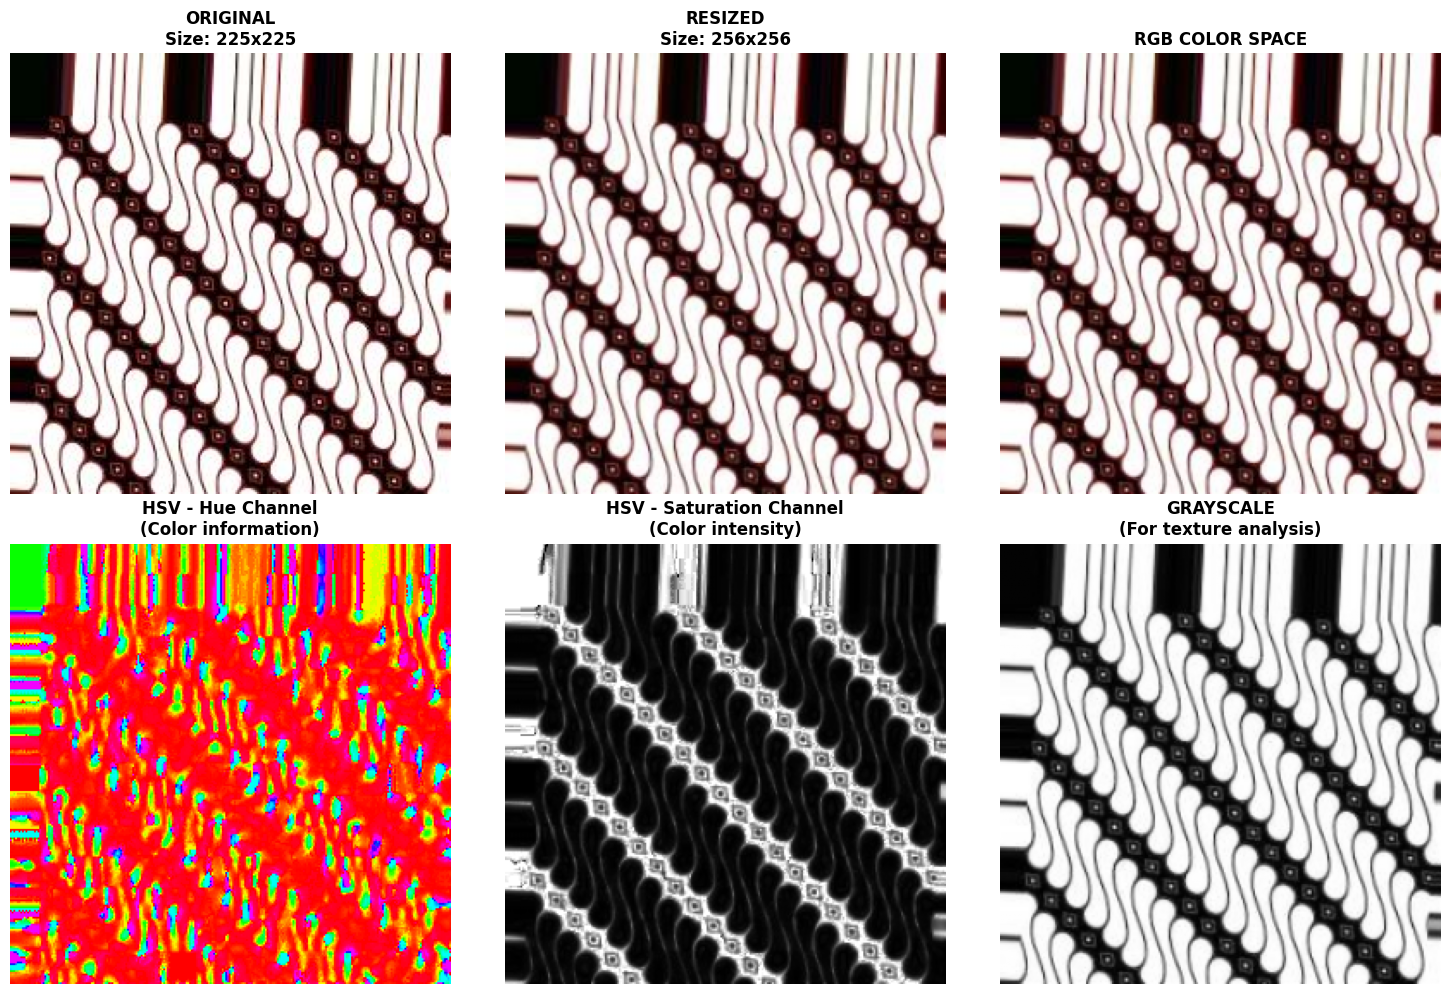


[OK] Preprocessing complete!
  Original -> Resized: (225, 225, 3) -> (256, 256, 3)
  Color spaces generated: RGB, HSV, Grayscale


In [10]:
# Apply preprocessing
resized_bgr, hsv_img, gray_img = preprocess_image(original_img, IMG_SIZE)

# Visualize preprocessing steps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original → Resized → RGB
axes[0, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'ORIGINAL\nSize: {original_img.shape[1]}x{original_img.shape[0]}', fontsize=12, weight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'RESIZED\nSize: {IMG_SIZE[0]}x{IMG_SIZE[1]}', fontsize=12, weight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('RGB COLOR SPACE', fontsize=12, weight='bold')
axes[0, 2].axis('off')

# Row 2: HSV channels
axes[1, 0].imshow(hsv_img[:,:,0], cmap='hsv')
axes[1, 0].set_title('HSV - Hue Channel\n(Color information)', fontsize=12, weight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(hsv_img[:,:,1], cmap='gray')
axes[1, 1].set_title('HSV - Saturation Channel\n(Color intensity)', fontsize=12, weight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(gray_img, cmap='gray')
axes[1, 2].set_title('GRAYSCALE\n(For texture analysis)', fontsize=12, weight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n[OK] Preprocessing complete!")
print(f"  Original -> Resized: {original_img.shape} -> {resized_bgr.shape}")
print(f"  Color spaces generated: RGB, HSV, Grayscale")

#### Step 2: HSV Color Moments Extraction

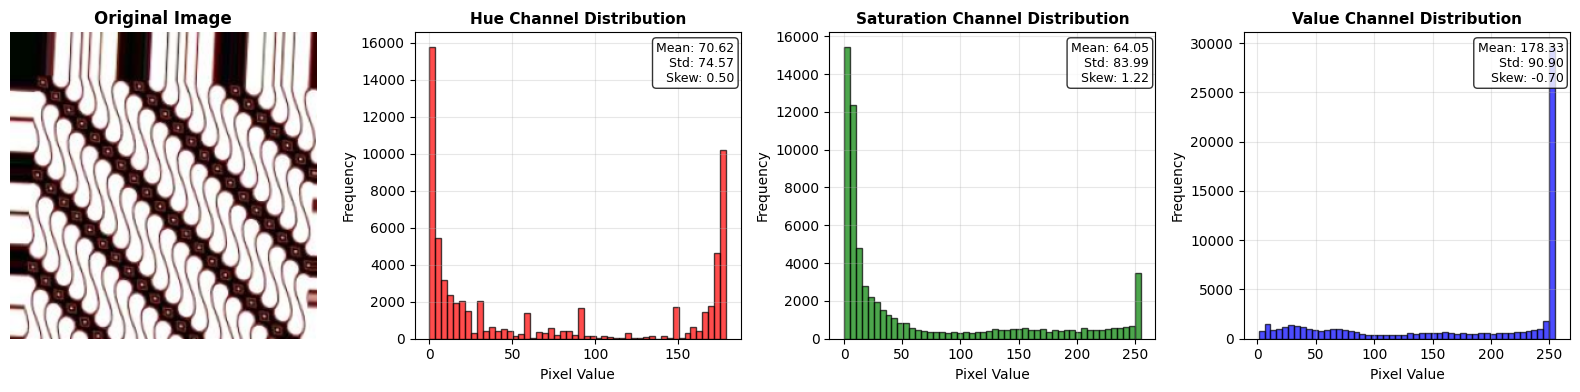


[OK] HSV Color Moments extracted!
  Feature vector shape: (9,)
  Features: [H_mean, H_std, H_skew, S_mean, S_std, S_skew, V_mean, V_std, V_skew]

  Extracted values:
    Hue: mean=70.62, std=74.57, skew=0.50
    Saturation: mean=64.05, std=83.99, skew=1.22
    Value: mean=178.33, std=90.90, skew=-0.70


In [11]:
# Extract HSV color moments
hsv_features = extract_hsv_color_moments(hsv_img)

# Visualize HSV features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Show HSV image
axes[0].imshow(cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=12, weight='bold')
axes[0].axis('off')

# Plot histograms for each HSV channel
channel_names = ['Hue', 'Saturation', 'Value']
colors = ['red', 'green', 'blue']

for i, (name, color) in enumerate(zip(channel_names, colors)):
    channel_data = hsv_img[:,:,i].flatten()
    axes[i+1].hist(channel_data, bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i+1].set_title(f'{name} Channel Distribution', fontsize=11, weight='bold')
    axes[i+1].set_xlabel('Pixel Value')
    axes[i+1].set_ylabel('Frequency')
    axes[i+1].grid(alpha=0.3)

    # Add statistics
    mean_val = hsv_features[i*3]
    std_val = hsv_features[i*3 + 1]
    skew_val = hsv_features[i*3 + 2]

    stats_text = f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}\nSkew: {skew_val:.2f}'
    axes[i+1].text(0.98, 0.97, stats_text, transform=axes[i+1].transAxes,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   fontsize=9)

plt.tight_layout()
plt.show()

print("\n[OK] HSV Color Moments extracted!")
print(f"  Feature vector shape: {hsv_features.shape}")
print(f"  Features: [H_mean, H_std, H_skew, S_mean, S_std, S_skew, V_mean, V_std, V_skew]")
print(f"\n  Extracted values:")
for i, channel in enumerate(['Hue', 'Saturation', 'Value']):
    print(f"    {channel}: mean={hsv_features[i*3]:.2f}, std={hsv_features[i*3+1]:.2f}, skew={hsv_features[i*3+2]:.2f}")

#### Step 3: GLCM Texture Features Extraction

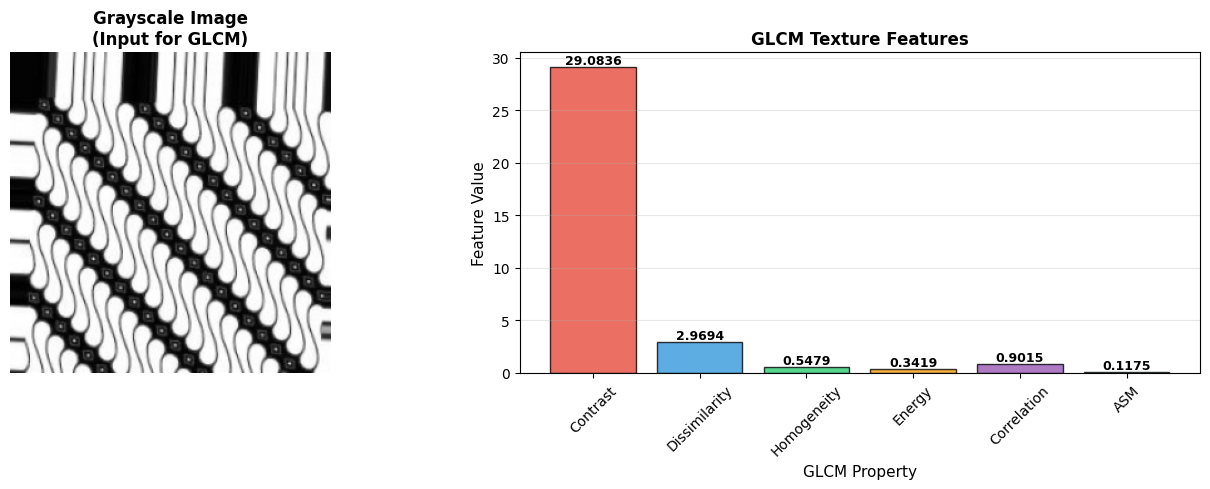


[OK] GLCM Texture Features extracted!
  Feature vector shape: (6,)
  Features:
    Contrast       : 29.083559
    Dissimilarity  : 2.969378
    Homogeneity    : 0.547933
    Energy         : 0.341921
    Correlation    : 0.901522
    ASM            : 0.117535


In [12]:
# Extract GLCM features
glcm_features = extract_glcm_features(gray_img, GLCM_DISTANCES, GLCM_ANGLES)

# Visualize GLCM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show grayscale image
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Grayscale Image\n(Input for GLCM)', fontsize=12, weight='bold')
axes[0].axis('off')

# Plot GLCM features as bar chart
feature_names = ['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation', 'ASM']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

bars = axes[1].bar(feature_names, glcm_features, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('GLCM Texture Features', fontsize=12, weight='bold')
axes[1].set_ylabel('Feature Value', fontsize=11)
axes[1].set_xlabel('GLCM Property', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, glcm_features):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

print("\n[OK] GLCM Texture Features extracted!")
print(f"  Feature vector shape: {glcm_features.shape}")
print(f"  Features:")
for name, val in zip(feature_names, glcm_features):
    print(f"    {name:15s}: {val:.6f}")

#### Step 4: LBP (Local Binary Pattern) Features Extraction

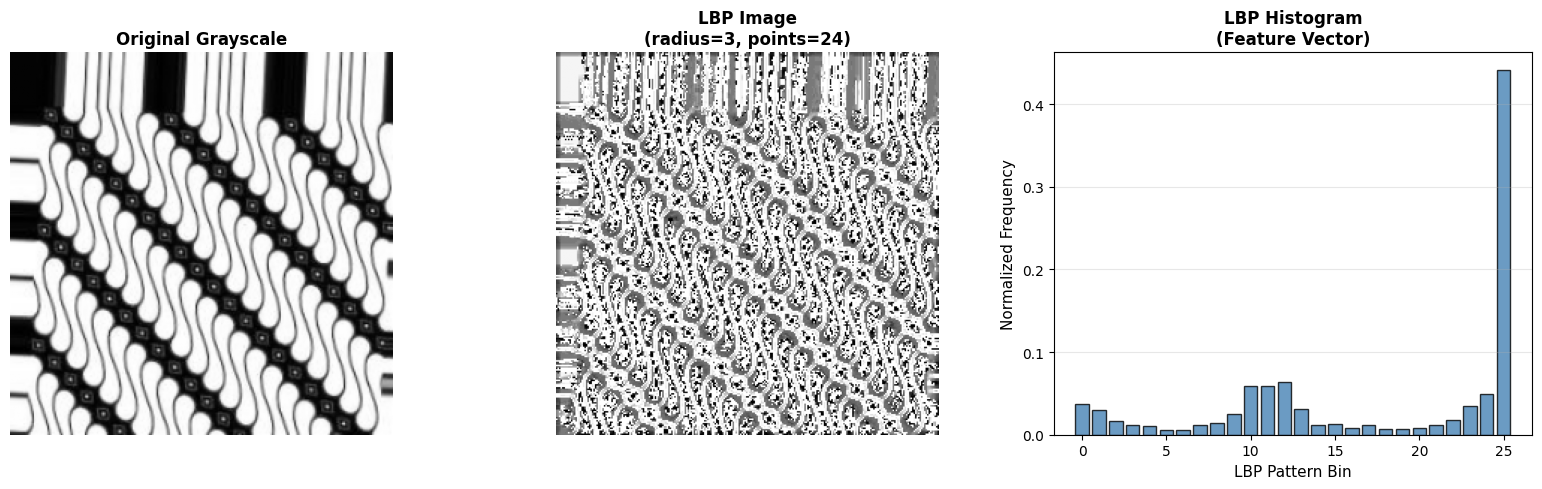


[OK] LBP Features extracted!
  Feature vector shape: (26,)
  LBP configuration: radius=3, points=24
  Number of bins: 26 (uniform LBP)

  Top 5 most frequent patterns:
    Bin 25: 0.4409
    Bin 12: 0.0639
    Bin 10: 0.0585
    Bin 11: 0.0584
    Bin 24: 0.0487


In [13]:
# Extract LBP features
lbp_features = extract_lbp_features(gray_img, LBP_RADIUS, LBP_N_POINTS)

# Compute LBP image for visualization
lbp_image = local_binary_pattern(gray_img, LBP_N_POINTS, LBP_RADIUS, method='uniform')

# Visualize LBP
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original grayscale
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale', fontsize=12, weight='bold')
axes[0].axis('off')

# LBP image
axes[1].imshow(lbp_image, cmap='gray')
axes[1].set_title(f'LBP Image\n(radius={LBP_RADIUS}, points={LBP_N_POINTS})', fontsize=12, weight='bold')
axes[1].axis('off')

# LBP histogram
n_bins = LBP_N_POINTS + 2
axes[2].bar(range(n_bins), lbp_features, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].set_title('LBP Histogram\n(Feature Vector)', fontsize=12, weight='bold')
axes[2].set_xlabel('LBP Pattern Bin', fontsize=11)
axes[2].set_ylabel('Normalized Frequency', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[OK] LBP Features extracted!")
print(f"  Feature vector shape: {lbp_features.shape}")
print(f"  LBP configuration: radius={LBP_RADIUS}, points={LBP_N_POINTS}")
print(f"  Number of bins: {n_bins} (uniform LBP)")
print(f"\n  Top 5 most frequent patterns:")
top_5_indices = np.argsort(lbp_features)[-5:][::-1]
for idx in top_5_indices:
    print(f"    Bin {idx:2d}: {lbp_features[idx]:.4f}")

#### Step 5: Combined Features (HSV + GLCM + LBP)

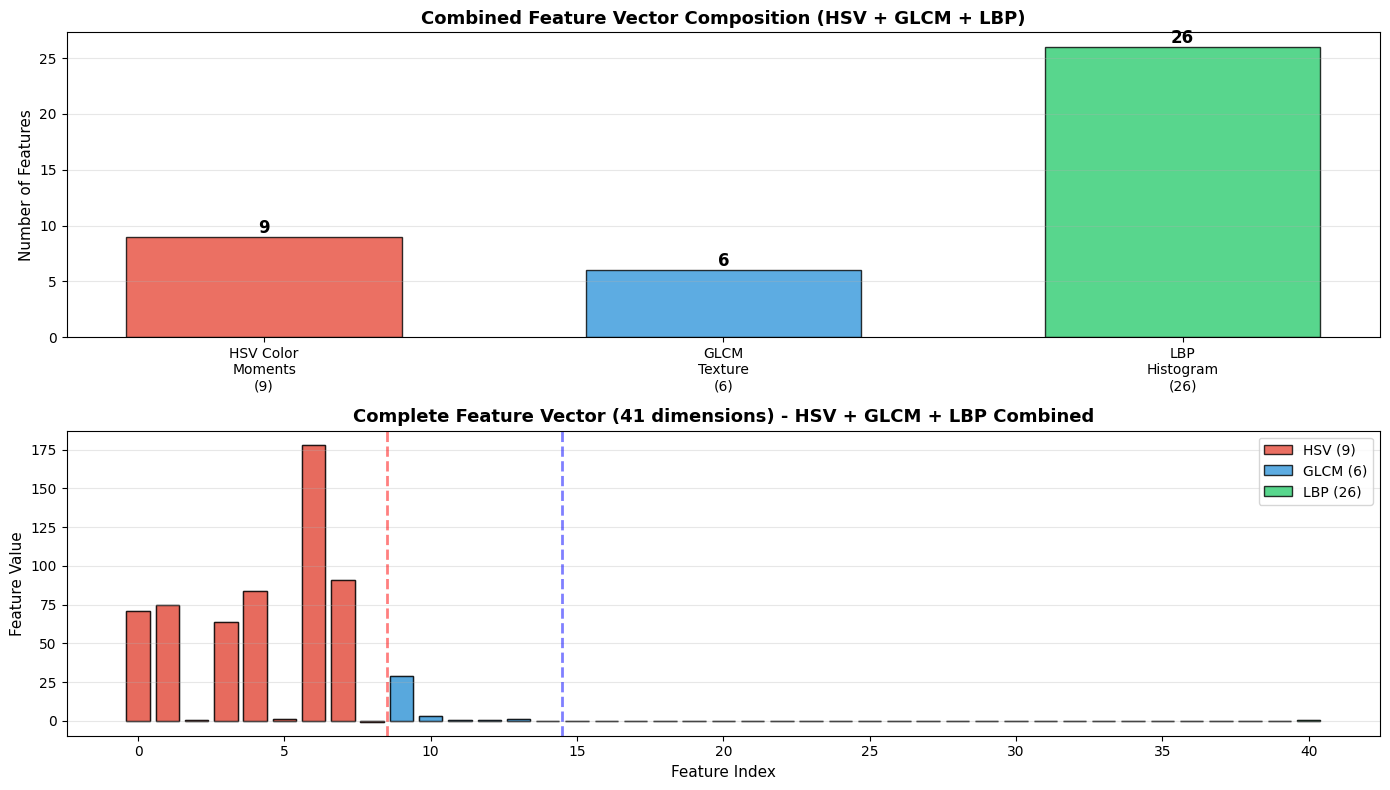


COMBINED FEATURE EXTRACTION SUMMARY
[OK] Total features extracted: 41

  Feature breakdown:
    - HSV Color Moments:   9 features (indices 0-8)
    - GLCM Texture:        6 features (indices 9-14)
    - LBP Histogram:      26 features (indices 15-40)

  Combined feature vector shape: (41,)
  Ready for machine learning pipeline!


In [14]:
# Combine all features
combined_features = np.concatenate([hsv_features, glcm_features, lbp_features])

# Visualize feature composition
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Feature vector breakdown
feature_counts = [len(hsv_features), len(glcm_features), len(lbp_features)]
feature_labels = ['HSV Color\nMoments\n(9)', 'GLCM\nTexture\n(6)', 'LBP\nHistogram\n(26)']
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes[0].bar(feature_labels, feature_counts, color=colors, edgecolor='black', alpha=0.8, width=0.6)
axes[0].set_title('Combined Feature Vector Composition (HSV + GLCM + LBP)', fontsize=13, weight='bold')
axes[0].set_ylabel('Number of Features', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars, feature_counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}', ha='center', va='bottom', fontsize=12, weight='bold')

# Full feature vector visualization
feature_ranges = [
    (0, 9, 'HSV (9)', '#e74c3c'),
    (9, 15, 'GLCM (6)', '#3498db'),
    (15, 41, 'LBP (26)', '#2ecc71')
]

x_positions = np.arange(len(combined_features))
axes[1].bar(x_positions, combined_features, color='lightgray', edgecolor='black', alpha=0.5)

# Color code by feature type
for start, end, label, color in feature_ranges:
    axes[1].bar(x_positions[start:end], combined_features[start:end],
               color=color, edgecolor='black', alpha=0.8, label=label)

axes[1].set_title('Complete Feature Vector (41 dimensions) - HSV + GLCM + LBP Combined', fontsize=13, weight='bold')
axes[1].set_xlabel('Feature Index', fontsize=11)
axes[1].set_ylabel('Feature Value', fontsize=11)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Add separators
axes[1].axvline(x=8.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].axvline(x=14.5, color='blue', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMBINED FEATURE EXTRACTION SUMMARY")
print("="*60)
print(f"[OK] Total features extracted: {len(combined_features)}")
print(f"\n  Feature breakdown:")
print(f"    - HSV Color Moments:  {len(hsv_features):2d} features (indices 0-8)")
print(f"    - GLCM Texture:       {len(glcm_features):2d} features (indices 9-14)")
print(f"    - LBP Histogram:      {len(lbp_features):2d} features (indices 15-40)")
print(f"\n  Combined feature vector shape: {combined_features.shape}")
print(f"  Ready for machine learning pipeline!")
print("="*60)

### 3.7 Image Quality Metrics (PSNR & MSE)

In [15]:
def compute_mse(img1, img2):
    """
    Compute Mean Squared Error between two images.

    Parameters:
    -----------
    img1, img2 : numpy.ndarray
        Images to compare (must have same shape)

    Returns:
    --------
    float
        MSE value
    """
    # Ensure images have same shape
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convert to float for accurate computation
    img1_float = img1.astype(np.float64)
    img2_float = img2.astype(np.float64)

    mse = np.mean((img1_float - img2_float) ** 2)
    return mse


def compute_psnr(img1, img2, max_pixel_value=255.0):
    """
    Compute Peak Signal-to-Noise Ratio between two images.

    Parameters:
    -----------
    img1, img2 : numpy.ndarray
        Images to compare (must have same shape)
    max_pixel_value : float
        Maximum possible pixel value (255 for 8-bit images)

    Returns:
    --------
    float
        PSNR value in dB
    """
    mse = compute_mse(img1, img2)

    if mse == 0:
        # Images are identical
        return float('inf')

    psnr = 20 * np.log10(max_pixel_value / np.sqrt(mse))
    return psnr

print("[OK] compute_mse() and compute_psnr() defined")

[OK] compute_mse() and compute_psnr() defined


In [ ]:
def save_features_to_cache(X, y, image_paths_labels, cache_file):
    os.makedirs(os.path.dirname(cache_file), exist_ok=True)

    cache_data = {
        'features': X,
        'labels': y,
        'image_paths_labels': image_paths_labels,
        'config': {
            'IMG_SIZE': IMG_SIZE,
            'LBP_RADIUS': LBP_RADIUS,
            'LBP_N_POINTS': LBP_N_POINTS,
            'GLCM_DISTANCES': GLCM_DISTANCES,
            'GLCM_ANGLES': GLCM_ANGLES
        }
    }

    np.save(cache_file, cache_data, allow_pickle=True)
    print(f"[OK] Features saved to cache: {cache_file}")
    print(f"  File size: {os.path.getsize(cache_file) / 1024 / 1024:.2f} MB")


def load_features_from_cache(cache_file):
    if not os.path.exists(cache_file):
        return None, None, None

    try:
        cache_data = np.load(cache_file, allow_pickle=True).item()

        # Verify config matches current settings
        config = cache_data.get('config', {})
        if (config.get('IMG_SIZE') != IMG_SIZE or
            config.get('LBP_RADIUS') != LBP_RADIUS or
            config.get('LBP_N_POINTS') != LBP_N_POINTS):
            print("[WARNING] Cache config mismatch - will re-extract features")
            return None, None, None

        X = cache_data['features']
        y = cache_data['labels']
        image_paths_labels = cache_data['image_paths_labels']

        print(f"[OK] Features loaded from cache: {cache_file}")
        print(f"  Samples: {len(X)}, Features: {X.shape[1]}")

        return X, y, image_paths_labels

    except Exception as e:
        print(f"[WARNING] Error loading cache: {e}")
        return None, None, None


def extract_single_image_features(args):
    img_path, label = args
    try:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            return None, label, img_path

        features = extract_features_for_image(img_bgr)
        return features, label, None
    except Exception as e:
        return None, label, img_path


def extract_features_parallel(image_paths_labels, dataset_name="Dataset", n_workers=None):
    if n_workers is None:
        n_workers = cpu_count()

    print(f"Extracting features from {dataset_name} using {n_workers} CPU cores...")
    print("This is MUCH faster than sequential processing!\n")

    # Use multiprocessing Pool
    with Pool(n_workers) as pool:
        results = list(tqdm(
            pool.imap(extract_single_image_features, image_paths_labels),
            total=len(image_paths_labels),
            desc=f"{dataset_name}"
        ))

    # Separate successful and failed extractions
    X_list = [r[0] for r in results if r[0] is not None]
    y_list = [r[1] for r in results if r[0] is not None]
    failed = [r[2] for r in results if r[2] is not None]

    X = np.array(X_list)
    y = np.array(y_list)

    return X, y, failed


def extract_or_load_features(image_paths_labels, cache_file, dataset_name="Dataset"):
    # Try to load from cache first
    if ENABLE_FEATURE_CACHE and not FORCE_REEXTRACT:
        X, y, cached_paths = load_features_from_cache(cache_file)
        if X is not None:
            print(f"[OK] Using cached features for {dataset_name}")
            return X, y, []

    # Extract features
    if USE_MULTIPROCESSING:
        # Use parallel processing (MUCH faster!)
        X, y, failed = extract_features_parallel(
            image_paths_labels,
            dataset_name,
            n_workers=N_WORKERS
        )
    else:
        # Sequential processing (slower)
        print(f"Extracting features from {dataset_name}...")
        print("This may take a while depending on dataset size...\n")

        X_list = []
        y_list = []
        failed = []

        for img_path, label in tqdm(image_paths_labels, desc=dataset_name):
            try:
                img_bgr = cv2.imread(img_path)
                if img_bgr is None:
                    failed.append(img_path)
                    continue

                features = extract_features_for_image(img_bgr)
                X_list.append(features)
                y_list.append(label)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                failed.append(img_path)

        X = np.array(X_list)
        y = np.array(y_list)

    print(f"\n[OK] {dataset_name} feature extraction complete!")
    print(f"  Samples: {len(X)}")
    print(f"  Feature dimension: {X.shape[1]}")
    print(f"  Failed images: {len(failed)}")

    # Save to cache
    if ENABLE_FEATURE_CACHE:
        save_features_to_cache(X, y, image_paths_labels, cache_file)

    return X, y, failed

print("[OK] Feature extraction functions defined:")
print("  - save_features_to_cache()")
print("  - load_features_from_cache()")
print("  - extract_single_image_features() [parallel worker]")
print("  - extract_features_parallel() [multiprocessing]")
print("  - extract_or_load_features() [main extraction function]")

[OK] Feature extraction functions defined:
  - save_features_to_cache()
  - load_features_from_cache()
  - extract_single_image_features() [parallel worker]
  - extract_features_parallel() [multiprocessing]
  - extract_or_load_features() [main extraction function]


### 3.8 Feature Caching (Save/Load)

## 4. Dataset Loading & Preprocessing

Load dataset dari folder train dan test yang sudah terpisah.

In [17]:
# Load training and test image paths
print("Loading training set...")
train_paths_labels = load_image_paths(TRAIN_DIR)
print(f"[OK] Found {len(train_paths_labels)} training images")

print("\nLoading test set...")
test_paths_labels = load_image_paths(TEST_DIR)
print(f"[OK] Found {len(test_paths_labels)} test images")

# Combine for statistics
all_paths_labels = train_paths_labels + test_paths_labels

if len(all_paths_labels) == 0:
    print(f"\n[WARNING] No images found in dataset directories!")
    print("Please check the dataset paths in configuration.")
else:
    # Get unique classes
    unique_classes = sorted(set([label for _, label in all_paths_labels]))
    print(f"\n[OK] Total images: {len(all_paths_labels)}")
    print(f"[OK] Number of classes: {len(unique_classes)}")

    print(f"\nDataset split:")
    print(f"  Training: {len(train_paths_labels)} images ({len(train_paths_labels)/len(all_paths_labels)*100:.1f}%)")
    print(f"  Test: {len(test_paths_labels)} images ({len(test_paths_labels)/len(all_paths_labels)*100:.1f}%)")

Loading training set...
[OK] Found 13337 training images

Loading test set...
[OK] Found 2868 test images

[OK] Total images: 16205
[OK] Number of classes: 19

Dataset split:
  Training: 13337 images (82.3%)
  Test: 2868 images (17.7%)
[OK] Found 13337 training images

Loading test set...
[OK] Found 2868 test images

[OK] Total images: 16205
[OK] Number of classes: 19

Dataset split:
  Training: 13337 images (82.3%)
  Test: 2868 images (17.7%)


### Feature Extraction dari Training Set

Ekstrak fitur HSV + GLCM + LBP dari training images.

In [18]:
# Extract features from TRAINING set (or load from cache)
# Use different cache file name for 20-class version
train_cache_file = os.path.join(CACHE_DIR, "train_features_20class.npy")
X_train, y_train, failed_train = extract_or_load_features(
    train_paths_labels,
    train_cache_file,
    "Training set (20 classes)"
)

[OK] Features loaded from cache: features_cache/train_features_20class.npy
  Samples: 14046, Features: 41
[OK] Using cached features for Training set (20 classes)


### Feature Extraction dari Test Set

Ekstrak fitur HSV + GLCM + LBP dari test images.

In [19]:
# Extract features from TEST set (or load from cache)
# Use different cache file name for 20-class version
test_cache_file = os.path.join(CACHE_DIR, "test_features_20class.npy")
X_test, y_test, failed_test = extract_or_load_features(
    test_paths_labels,
    test_cache_file,
    "Test set (20 classes)"
)

# Handle NaN values (replace with 0 or use mean imputation)
print("\nChecking for NaN values...")
nan_count_train = np.isnan(X_train).sum()
nan_count_test = np.isnan(X_test).sum()

if nan_count_train > 0 or nan_count_test > 0:
    print(f"[WARNING] Found NaN values:")
    print(f"  - Training set: {nan_count_train} NaN values")
    print(f"  - Test set: {nan_count_test} NaN values")
    print(f"  Replacing NaN with 0...")

    # Replace NaN with 0 (safe for normalized features)
    X_train = np.nan_to_num(X_train, nan=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0)

    print(f"[OK] NaN values handled successfully!")
else:
    print("[OK] No NaN values found!")

# Combine for overall dataset info
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

print(f"\n" + "="*60)
print("DATASET SUMMARY (20 CLASSES)")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"  - Training: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Feature dimension: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Total failed images: {len(failed_train) + len(failed_test)}")

[OK] Features loaded from cache: features_cache/test_features_20class.npy
  Samples: 3023, Features: 41
[OK] Using cached features for Test set (20 classes)

Checking for NaN values...
[WARNING] Found NaN values:
  - Training set: 220 NaN values
  - Test set: 42 NaN values
  Replacing NaN with 0...
[OK] NaN values handled successfully!

DATASET SUMMARY (20 CLASSES)
Total samples: 17069
  - Training: 14046 (82.3%)
  - Test: 3023 (17.7%)
Feature dimension: 41
Number of classes: 20
Total failed images: 0


## 5. Model Training

Bangun dan latih pipeline machine learning: StandardScaler → PCA → SVM.

In [20]:
# Build the machine learning pipeline
print("Building ML pipeline...")
print(f"Compute mode: {'GPU (CUDA)' if USE_GPU else 'CPU'}\n")

if USE_GPU:
    # GPU-accelerated pipeline using cuML
    print("[GPU] Using GPU-accelerated cuML components!")

    # Note: cuML SVC and PCA work with cuDF/numpy on GPU
    # For sklearn Pipeline compatibility, we'll use a custom approach
    from sklearn.base import BaseEstimator, TransformerMixin

    class GPUScaler(BaseEstimator, TransformerMixin):
        """GPU-accelerated StandardScaler wrapper"""
        def __init__(self):
            self.mean_ = None
            self.std_ = None

        def fit(self, X, y=None):
            self.mean_ = np.mean(X, axis=0)
            self.std_ = np.std(X, axis=0)
            return self

        def transform(self, X):
            return (X - self.mean_) / (self.std_ + 1e-8)

    pipeline = Pipeline([
        ('scaler', GPUScaler()),
        ('pca', cuPCA(n_components=PCA_VARIANCE)),
        ('svm', cuSVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                      class_weight='balanced'))
    ])

else:
    # CPU pipeline using sklearn
    print("[CPU] Using CPU-based scikit-learn components")

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=PCA_VARIANCE)),
        ('svm', SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                    class_weight='balanced', random_state=RANDOM_STATE))
    ])

print("\n[OK] Pipeline created:")
print("  1. StandardScaler - Feature normalization")
print(f"  2. PCA - Retain {PCA_VARIANCE*100}% variance")
print(f"  3. SVM - kernel={SVM_KERNEL}, C={SVM_C}, gamma={SVM_GAMMA}")
print(f"     class_weight='balanced' - Handle class imbalance")
print(f"  Acceleration: {'GPU (cuML)' if USE_GPU else 'CPU (sklearn)'}")

Building ML pipeline...
Compute mode: CPU

[CPU] Using CPU-based scikit-learn components

[OK] Pipeline created:
  1. StandardScaler - Feature normalization
  2. PCA - Retain 95.0% variance
  3. SVM - kernel=rbf, C=10, gamma=scale
     class_weight='balanced' - Handle class imbalance
  Acceleration: CPU (sklearn)


In [21]:
# Train the pipeline
print("Training the model...")
print("This may take several minutes...\n")

pipeline.fit(X_train, y_train)

print("[OK] Model training complete!")

# Check PCA components
n_components_kept = pipeline.named_steps['pca'].n_components_
explained_variance = pipeline.named_steps['pca'].explained_variance_ratio_.sum()

print(f"\nPCA Information:")
print(f"  Original features: {X_train.shape[1]}")
print(f"  PCA components kept: {n_components_kept}")
print(f"  Total explained variance: {explained_variance*100:.2f}%")

Training the model...
This may take several minutes...

[OK] Model training complete!

PCA Information:
  Original features: 41
  PCA components kept: 17
  Total explained variance: 95.16%
[OK] Model training complete!

PCA Information:
  Original features: 41
  PCA components kept: 17
  Total explained variance: 95.16%


### Model Evaluation - Accuracy Metrics

In [22]:
# Compute training and testing accuracy
print("Evaluating model performance...\n")

print("[1/2] Computing training accuracy...")
train_acc = pipeline.score(X_train, y_train)
print(f"      Training Accuracy: {train_acc*100:.2f}%")

print("\n[2/2] Computing test accuracy...")
test_acc = pipeline.score(X_test, y_test)
print(f"      Testing Accuracy: {test_acc*100:.2f}%")

# Use simple holdout validation instead
cv_scores = np.array([test_acc])  # Use test accuracy as proxy
print(f"Using Test Accuracy as validation: {test_acc*100:.2f}%")

# Store results in DataFrame
model_name = f"HSV+GLCM+LBP + PCA + SVM-{SVM_KERNEL.upper()}"
results_df = pd.DataFrame({
    'model_name': [model_name],
    'train_acc': [train_acc],
    'test_acc': [test_acc],
    'cv_mean_acc': [cv_scores.mean()],
    'cv_std_acc': [cv_scores.std()]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
display(results_df)

Evaluating model performance...

[1/2] Computing training accuracy...
      Training Accuracy: 99.39%

[2/2] Computing test accuracy...
      Training Accuracy: 99.39%

[2/2] Computing test accuracy...
      Testing Accuracy: 97.29%
Using Test Accuracy as validation: 97.29%

MODEL PERFORMANCE SUMMARY
      Testing Accuracy: 97.29%
Using Test Accuracy as validation: 97.29%

MODEL PERFORMANCE SUMMARY


,model_name,train_acc,test_acc,cv_mean_acc,cv_std_acc
0,HSV+GLCM+LBP + PCA + SVM-RBF,0.993877,0.972875,0.972875,0.0


## 6. Evaluation & Metrics

Evaluasi detail performa model dengan berbagai metrik.

### Classification Report

In [23]:
# Generate predictions on test set
y_pred = pipeline.predict(X_test)

# Display classification report
print("="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_pred))

# Store classification report as DataFrame for later use
from sklearn.metrics import classification_report as clf_report
report_dict = clf_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\nClassification Report DataFrame:")
display(report_df)

CLASSIFICATION REPORT (Test Set)
                           precision    recall  f1-score   support

              Bali_Barong       0.94      0.98      0.96       152
        JawaTengah_Blekok       1.00      1.00      1.00       151
    JawaTengah_JayaKusuma       1.00      1.00      1.00       152
 JawaTengah_KembangSepatu       1.00      1.00      1.00       151
 JawaTengah_LurikSemangka       1.00      1.00      1.00       152
  JawaTengah_ParangKusumo       0.99      0.99      0.99       151
  JawaTengah_ParangSlobog       0.98      1.00      0.99       152
    JawaTengah_Semarangan       1.00      1.00      1.00       150
       JawaTengah_Truntum       0.95      0.88      0.91       151
   KalimantanBarat_Insang       0.97      0.97      0.97       151
         Kalimantan_Dayak       1.00      1.00      1.00       150
            Lampung_Gajah       0.95      0.94      0.95       153
              Papua_Asmat       0.97      0.99      0.98       150
        Papua_Cendrawasih   

,precision,recall,f1-score,support
Bali_Barong,0.943038,0.980263,0.961290,152.000000
JawaTengah_Blekok,1.000000,1.000000,1.000000,151.000000
JawaTengah_JayaKusuma,1.000000,1.000000,1.000000,152.000000
JawaTengah_KembangSepatu,1.000000,1.000000,1.000000,151.000000
JawaTengah_LurikSemangka,1.000000,1.000000,1.000000,152.000000
JawaTengah_ParangKusumo,0.993333,0.986755,0.990033,151.000000
JawaTengah_ParangSlobog,0.980645,1.000000,0.990228,152.000000
JawaTengah_Semarangan,1.000000,1.000000,1.000000,150.000000
JawaTengah_Truntum,0.950000,0.880795,0.914089,151.000000
KalimantanBarat_Insang,0.967105,0.973510,0.970297,151.000000


### Confusion Matrix

In [24]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix computed.")
print(f"Shape: {cm.shape}")
print(f"\nConfusion Matrix:\n{cm}")

Confusion Matrix computed.
Shape: (20, 20)

Confusion Matrix:
[[149   0   0   0   0   0   0   0   0   2   0   1   0   0   0   0   0   0
    0   0]
 [  0 151   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0 152   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0 151   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0 152   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0 149   0   0   0   0   0   0   0   0   0   0   0   1
    0   1]
 [  0   0   0   0   0   0 152   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0 150   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  2   0   0   0   0   0   1   0 133   0   0   0   0   1   2   2   1   8
    0   1]
 [  1   0   0   0   0   0   0   0   0 147   0   0   0   2   0   0   0   1
    0   0]
 [  0   0   0   0   0   0   0   0   0   0 150   0   0   0   0   0   0   0
    0   0]
 [ 

### PSNR & MSE Analysis

In [25]:
# Analyze PSNR and MSE for a subset of images
print(f"Analyzing PSNR and MSE for {N_PSNR_MSE_SAMPLES} random images...")

# Randomly sample indices from all images
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(all_paths_labels),
                                  size=min(N_PSNR_MSE_SAMPLES, len(all_paths_labels)),
                                  replace=False)

psnr_mse_data = []

for idx in tqdm(sample_indices, desc="Computing PSNR/MSE"):
    img_path, label = all_paths_labels[idx]

    try:
        # Load original image
        original_img = cv2.imread(img_path)

        if original_img is None:
            continue

        # Preprocess image
        _, _, gray_img = preprocess_image(original_img, IMG_SIZE)

        # Convert original to grayscale for comparison
        original_gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

        # Compute MSE and PSNR
        mse = compute_mse(original_gray, gray_img)
        psnr = compute_psnr(original_gray, gray_img)

        psnr_mse_data.append({
            'filename': os.path.basename(img_path),
            'class': label,
            'MSE': mse,
            'PSNR': psnr
        })
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

# Create DataFrame
psnr_mse_df = pd.DataFrame(psnr_mse_data)

print("\n" + "="*60)
print("PSNR & MSE STATISTICS")
print("="*60)
print(psnr_mse_df.describe())

print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
display(psnr_mse_df.head(10))

Analyzing PSNR and MSE for 100 random images...


Computing PSNR/MSE: 100%|██████████| 100/100 [00:00<00:00, 252.41it/s]


PSNR & MSE STATISTICS
               MSE        PSNR
count   100.000000  100.000000
mean    159.828178   29.996002
std     281.222138    5.875021
min       1.439754   15.259434
25%      25.158769   25.477132
50%      61.238834   30.260553
75%     184.253475   34.124337
max    1937.032558   46.547920

SAMPLE DATA


,filename,class,MSE,PSNR
0,Lontara_0852.jpg,SulawesiSelatan_Lontara,14.752277,36.442213
1,CeplokLiring_0511.jpg,Yogyakarta_CeplokLiring,50.403332,31.106211
2,LurikSemangka_0707.jpg,JawaTengah_LurikSemangka,61.415958,30.247991
3,LurikSemangka_0365.jpg,JawaTengah_LurikSemangka,14.685947,36.461784
4,Asmat_0117.jpg,Papua_Asmat,17.574538,35.681965
5,Semarangan_0224.JPG,JawaTengah_Semarangan,1937.032558,15.259434
6,Gajah_0037.jpg,Lampung_Gajah,286.048280,23.566410
7,Truntum_0706.jpg,JawaTengah_Truntum,181.646869,25.538524
8,Sidoluhur_0770.jpg,JawaTengah_Sidoluhur,18.291075,35.508411
9,Megamendung_0076.jpg,JawaBarat_Megamendung,34.728789,32.723907


## 7. ONNX Model Export

Konversi model sklearn ke format ONNX untuk deployment.

In [26]:
# Convert the trained pipeline to ONNX format
print("Converting model to ONNX format...")

if USE_GPU:
    print("[NOTE] cuML models need to be converted to sklearn format for ONNX export")
    print("Converting GPU model to CPU-compatible sklearn model...")

    # For GPU models, we need to recreate as sklearn model
    # This is a limitation of ONNX conversion
    try:
        # Extract learned parameters and create sklearn equivalent
        from sklearn.svm import SVC as skSVC
        from sklearn.decomposition import PCA as skPCA

        # Recreate pipeline with sklearn components
        cpu_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', skPCA(n_components=pipeline.named_steps['pca'].n_components_)),
            ('svm', skSVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA))
        ])

        # Retrain on CPU (quick since model is already trained)
        print("Re-training with sklearn for ONNX compatibility...")
        cpu_pipeline.fit(X_train, y_train)
        export_pipeline = cpu_pipeline

    except Exception as e:
        print(f"[WARNING] Could not convert GPU model: {e}")
        print("Skipping ONNX export. GPU model is still available for predictions.")
        export_pipeline = None
else:
    export_pipeline = pipeline

# Proceed with ONNX export if we have a compatible pipeline
if export_pipeline is not None:
    # Define initial types for ONNX conversion
    initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

    try:
        onnx_model = convert_sklearn(
            export_pipeline,
            initial_types=initial_type,
            target_opset=12
        )

        # Save ONNX model
        with open(MODEL_NAME, "wb") as f:
            f.write(onnx_model.SerializeToString())

        print(f"[OK] Model successfully exported to: {MODEL_NAME}")

        # Verify the model
        onnx_model_check = onnx.load(MODEL_NAME)
        onnx.checker.check_model(onnx_model_check)
        print("[OK] ONNX model validation passed!")

        # Display model info
        print(f"\nONNX Model Information:")
        print(f"  IR Version: {onnx_model_check.ir_version}")
        print(f"  Producer: {onnx_model_check.producer_name}")
        print(f"  Opset Version: {onnx_model_check.opset_import[0].version}")

    except Exception as e:
        print(f"[ERROR] Error during ONNX conversion: {e}")
        print("The model will still be available as a pipeline object.")
else:
    print("[WARNING] ONNX export skipped. The trained GPU model is still available for predictions.")

Converting model to ONNX format...
[OK] Model successfully exported to: Batik_Group7(20C).onnx
[OK] ONNX model validation passed!

ONNX Model Information:
  IR Version: 7
  Producer: skl2onnx
  Opset Version: 11


### Save Configuration for Gradio App

Simpan konfigurasi model dalam format JSON untuk aplikasi Gradio.

In [27]:
import json

# Save configuration for Gradio app
print("Saving configuration for Gradio app...")

# Get unique class names
unique_classes = np.unique(y_train)

config_data = {
    'class_names': unique_classes.tolist(),
    'num_classes': len(unique_classes),
    'IMG_SIZE': list(IMG_SIZE),
    'LBP_RADIUS': int(LBP_RADIUS),
    'LBP_N_POINTS': int(LBP_N_POINTS),
    'GLCM_DISTANCES': GLCM_DISTANCES,
    'GLCM_ANGLES': GLCM_ANGLES.tolist() if isinstance(GLCM_ANGLES, np.ndarray) else GLCM_ANGLES,
    'model_type': 'SVM',
    'feature_extraction': 'HSV+GLCM+LBP',
    'total_features': 41
}

config_path = "batik_config(20C).json"
with open(config_path, 'w') as f:
    json.dump(config_data, f, indent=2)

print(f"[OK] Configuration saved to: {config_path}")
print(f"  Classes: {len(unique_classes)}")
print(f"  Configuration includes:")
print(f"    - Class names ({len(unique_classes)} classes)")
print(f"    - Image size: {IMG_SIZE}")
print(f"    - LBP parameters: radius={LBP_RADIUS}, points={LBP_N_POINTS}")
print(f"    - GLCM parameters")
print(f"\n[INFO] Files needed for Gradio app:")
print(f"  1. {MODEL_NAME} (ONNX model)")
print(f"  2. {config_path} (Configuration)")
print(f"\n[INFO] Run Gradio app with:")
print(f"  python app_gradio_classical.py")

Saving configuration for Gradio app...
[OK] Configuration saved to: batik_config(20C).json
  Classes: 20
  Configuration includes:
    - Class names (20 classes)
    - Image size: (256, 256)
    - LBP parameters: radius=3, points=24
    - GLCM parameters

[INFO] Files needed for Gradio app:
  1. Batik_Group7(20C).onnx (ONNX model)
  2. batik_config(20C).json (Configuration)

[INFO] Run Gradio app with:
  python app_gradio_classical.py


## 8. Visualisasi Hasil

Visualisasi komprehensif dari hasil klasifikasi dan performa model.

### 8.1 Sample Predictions Visualization

Visualizing 6 sample predictions from test set...
Features used: HSV (9) + GLCM (6) + LBP (26) = 41 features total



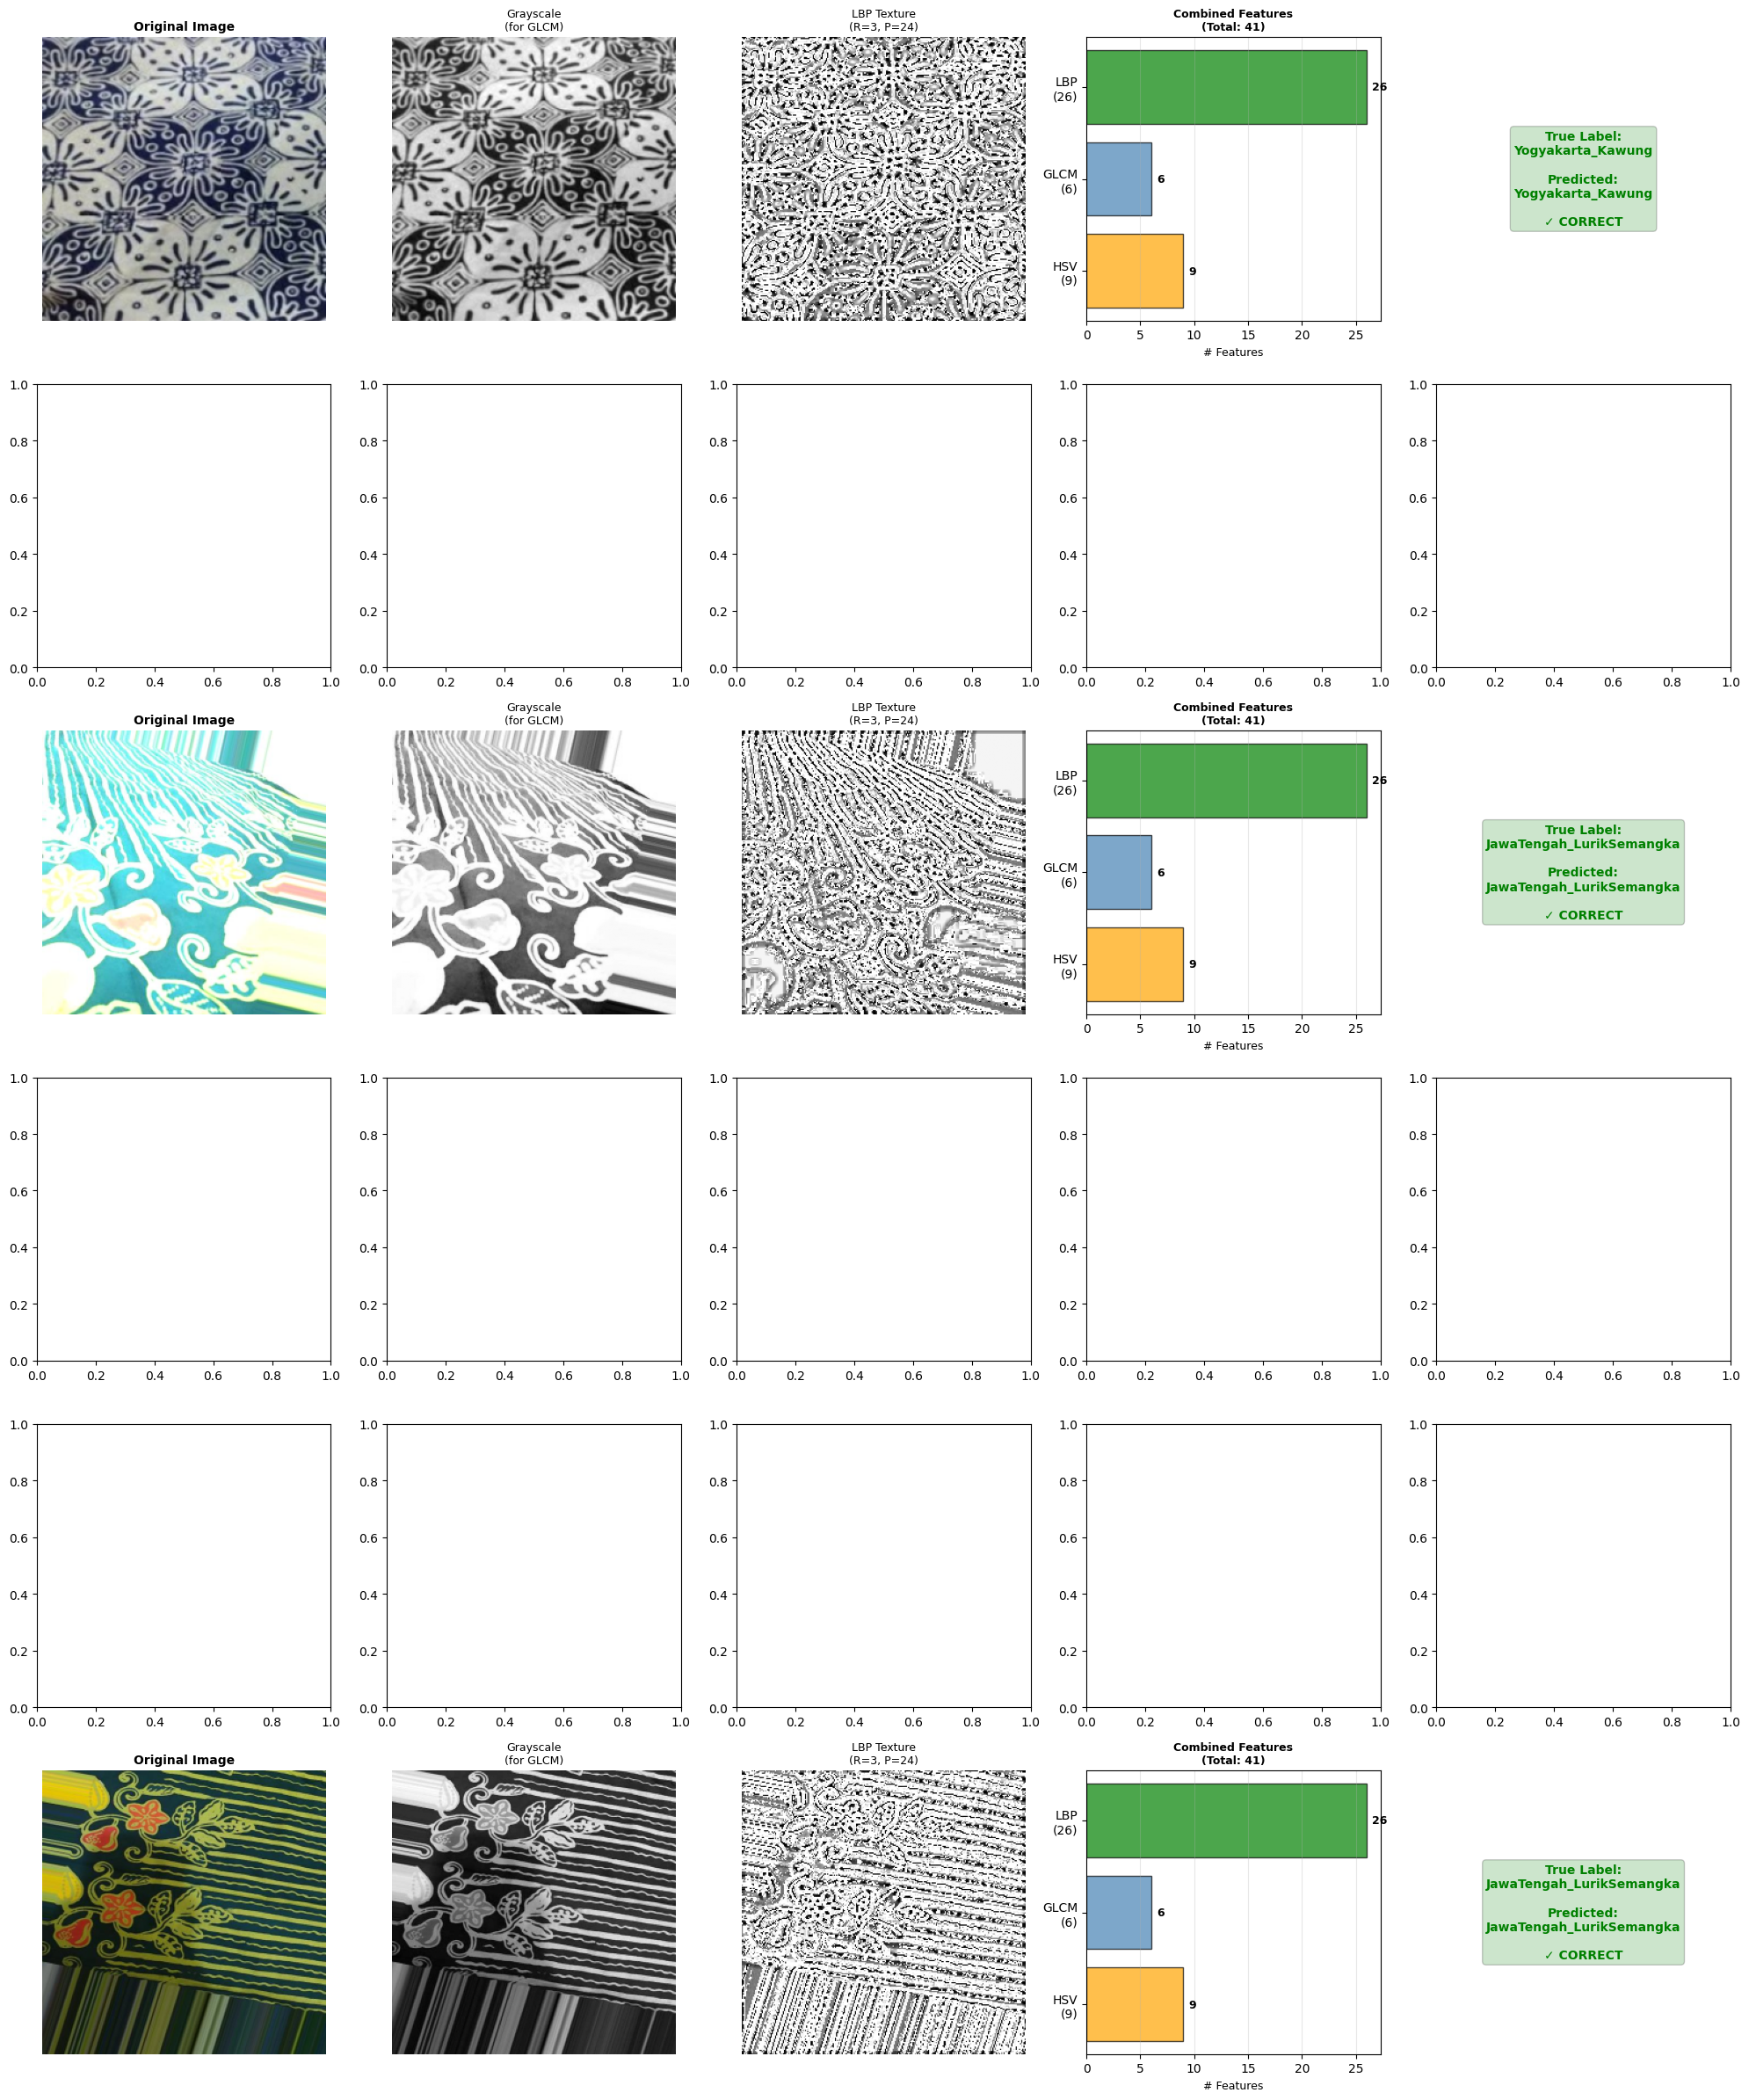

[OK] Sample predictions visualized with COMBINED features (HSV + GLCM + LBP)
     - Original image + preprocessing steps
     - LBP texture pattern visualization
     - Feature breakdown showing all 41 features used


In [28]:
# Visualize sample predictions with COMBINED features (HSV + GLCM + LBP)
from skimage.feature import local_binary_pattern

print(f"Visualizing {N_SAMPLE_IMAGES} sample predictions from test set...")
print("Features used: HSV (9) + GLCM (6) + LBP (26) = 41 features total\n")

# Randomly sample test indices
np.random.seed(RANDOM_STATE)
test_indices = np.random.choice(len(X_test), size=min(N_SAMPLE_IMAGES, len(X_test)), replace=False)

# Create figure with 5 columns
fig, axes = plt.subplots(N_SAMPLE_IMAGES, 5, figsize=(20, 4*N_SAMPLE_IMAGES))

if N_SAMPLE_IMAGES == 1:
    axes = axes.reshape(1, -1)

for i, idx in enumerate(test_indices):
    # Get the actual image path
    test_label = y_test[idx]
    test_features = X_test[idx]

    # Find a matching image from the test dataset
    matching_images = [path for path, label in test_paths_labels if label == test_label]
    if len(matching_images) > 0:
        img_path = np.random.choice(matching_images)

        # Load and preprocess
        original_img = cv2.imread(img_path)
        resized_bgr, hsv_img, gray_img = preprocess_image(original_img, IMG_SIZE)

        # Extract LBP for visualization
        lbp_img = local_binary_pattern(gray_img, LBP_N_POINTS, LBP_RADIUS, method='uniform')

        # Get prediction
        prediction = pipeline.predict([test_features])[0]
        is_correct = (prediction == test_label)

        # Plot 1: Original image
        axes[i, 0].imshow(cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Original Image", fontsize=10, weight='bold')
        axes[i, 0].axis('off')

        # Plot 2: Grayscale (for GLCM)
        axes[i, 1].imshow(gray_img, cmap='gray')
        axes[i, 1].set_title("Grayscale\n(for GLCM)", fontsize=9)
        axes[i, 1].axis('off')

        # Plot 3: LBP texture pattern
        axes[i, 2].imshow(lbp_img, cmap='gray')
        axes[i, 2].set_title(f"LBP Texture\n(R={LBP_RADIUS}, P={LBP_N_POINTS})", fontsize=9)
        axes[i, 2].axis('off')

        # Plot 4: Feature breakdown (bar chart)
        axes[i, 3].barh(['HSV\n(9)', 'GLCM\n(6)', 'LBP\n(26)'],
                        [9, 6, 26],
                        color=['orange', 'steelblue', 'green'],
                        edgecolor='black', alpha=0.7)
        axes[i, 3].set_xlabel('# Features', fontsize=9)
        axes[i, 3].set_title('Combined Features\n(Total: 41)', fontsize=9, weight='bold')
        axes[i, 3].grid(axis='x', alpha=0.3)

        # Add feature counts on bars
        for j, (count, feature_type) in enumerate(zip([9, 6, 26], ['HSV', 'GLCM', 'LBP'])):
            axes[i, 3].text(count + 0.5, j, f'{count}', va='center', fontsize=9, weight='bold')

        # Plot 5: Prediction info
        axes[i, 4].axis('off')
        color = 'green' if is_correct else 'red'
        status = "✓ CORRECT" if is_correct else "✗ INCORRECT"

        info_text = f"True Label:\n{test_label}\n\n"
        info_text += f"Predicted:\n{prediction}\n\n"
        info_text += f"{status}"

        axes[i, 4].text(0.5, 0.5, info_text,
                       ha='center', va='center',
                       fontsize=10,
                       bbox=dict(boxstyle='round', facecolor=color, alpha=0.2),
                       color=color, weight='bold')

plt.tight_layout()
plt.show()

print("[OK] Sample predictions visualized with COMBINED features (HSV + GLCM + LBP)")
print("     - Original image + preprocessing steps")
print("     - LBP texture pattern visualization")
print("     - Feature breakdown showing all 41 features used")

### 8.2 Class Distribution Histogram

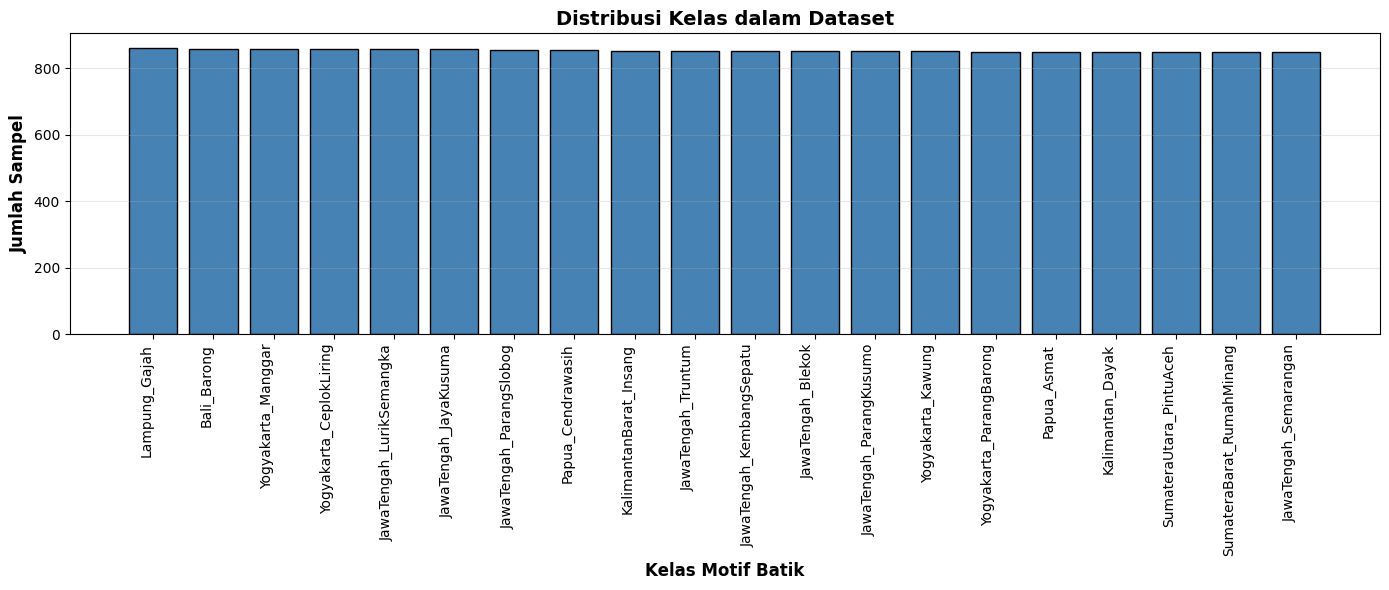

[OK] Total classes: 20
[OK] Total samples: 17069


In [29]:
# Plot class distribution
plt.figure(figsize=(14, 6))

# Count samples per class
class_names, class_counts = np.unique(y, return_counts=True)

# Sort by count (descending)
sorted_indices = np.argsort(class_counts)[::-1]
class_names_sorted = class_names[sorted_indices]
class_counts_sorted = class_counts[sorted_indices]

# Create bar plot
plt.bar(range(len(class_names_sorted)), class_counts_sorted, color='steelblue', edgecolor='black')
plt.xlabel('Kelas Motif Batik', fontsize=12, weight='bold')
plt.ylabel('Jumlah Sampel', fontsize=12, weight='bold')
plt.title('Distribusi Kelas dalam Dataset', fontsize=14, weight='bold')
plt.xticks(range(len(class_names_sorted)), class_names_sorted, rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[OK] Total classes: {len(class_names)}")
print(f"[OK] Total samples: {len(y)}")

### 8.3 PSNR & MSE Histograms

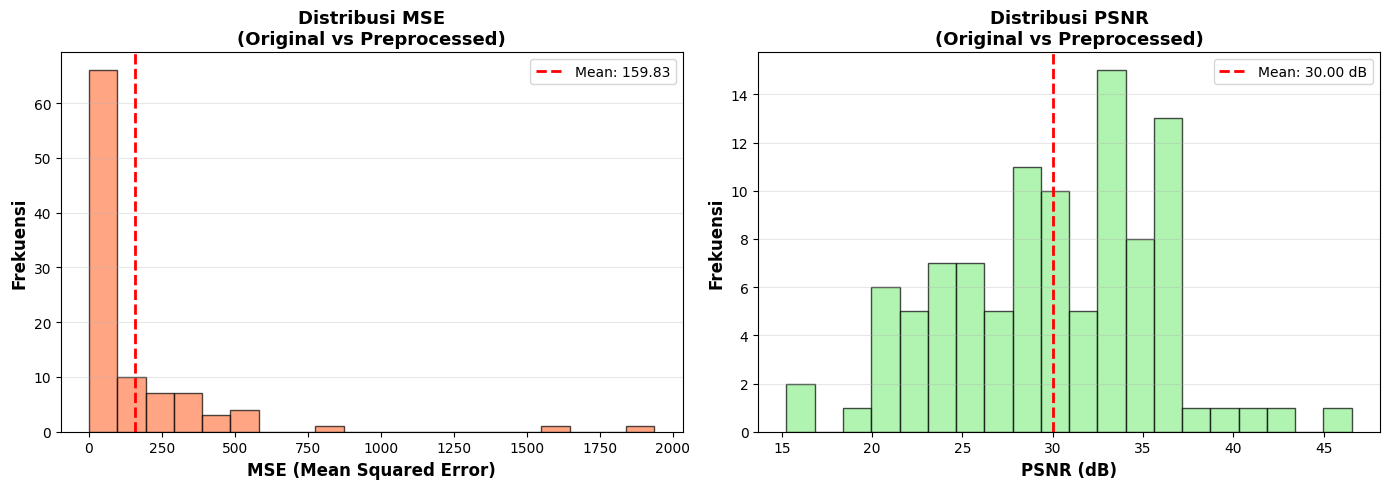

[OK] PSNR & MSE histograms plotted
  Mean MSE: 159.8282 ± 281.2221
  Mean PSNR: 30.00 ± 5.88 dB


In [30]:
# Plot PSNR and MSE distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE histogram
axes[0].hist(psnr_mse_df['MSE'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MSE (Mean Squared Error)', fontsize=12, weight='bold')
axes[0].set_ylabel('Frekuensi', fontsize=12, weight='bold')
axes[0].set_title('Distribusi MSE\n(Original vs Preprocessed)', fontsize=13, weight='bold')
axes[0].axvline(psnr_mse_df['MSE'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {psnr_mse_df["MSE"].mean():.2f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# PSNR histogram
axes[1].hist(psnr_mse_df['PSNR'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('PSNR (dB)', fontsize=12, weight='bold')
axes[1].set_ylabel('Frekuensi', fontsize=12, weight='bold')
axes[1].set_title('Distribusi PSNR\n(Original vs Preprocessed)', fontsize=13, weight='bold')
axes[1].axvline(psnr_mse_df['PSNR'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {psnr_mse_df["PSNR"].mean():.2f} dB')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("[OK] PSNR & MSE histograms plotted")
print(f"  Mean MSE: {psnr_mse_df['MSE'].mean():.4f} ± {psnr_mse_df['MSE'].std():.4f}")
print(f"  Mean PSNR: {psnr_mse_df['PSNR'].mean():.2f} ± {psnr_mse_df['PSNR'].std():.2f} dB")

### 8.4 Model Accuracy Comparison Table & Chart

MODEL PERFORMANCE TABLE


,model_name,train_acc,test_acc,cv_mean_acc,cv_std_acc
0,HSV+GLCM+LBP + PCA + SVM-RBF,0.993877,0.972875,0.972875,0.0


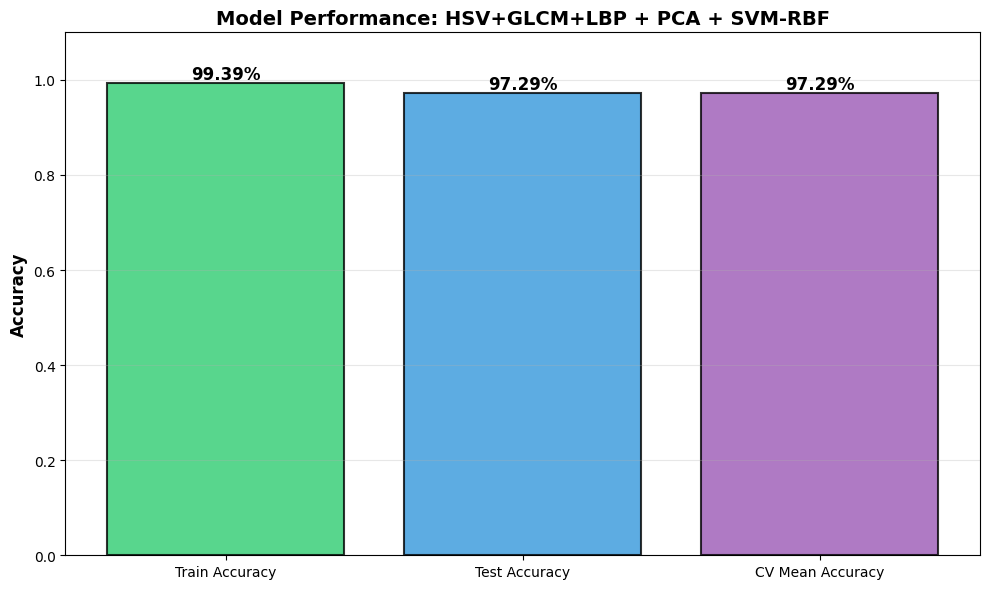

[OK] Model accuracy comparison visualized


In [31]:
# Display results table
print("="*70)
print("MODEL PERFORMANCE TABLE")
print("="*70)
display(results_df)

# Plot accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Train Accuracy', 'Test Accuracy', 'CV Mean Accuracy']
values = [results_df['train_acc'].values[0],
          results_df['test_acc'].values[0],
          results_df['cv_mean_acc'].values[0]]

bars = ax.bar(metrics, values, color=['#2ecc71', '#3498db', '#9b59b6'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val*100:.2f}%',
            ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Accuracy', fontsize=12, weight='bold')
ax.set_title(f'Model Performance: {model_name}', fontsize=14, weight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("[OK] Model accuracy comparison visualized")

### 8.5 Confusion Matrix Heatmap

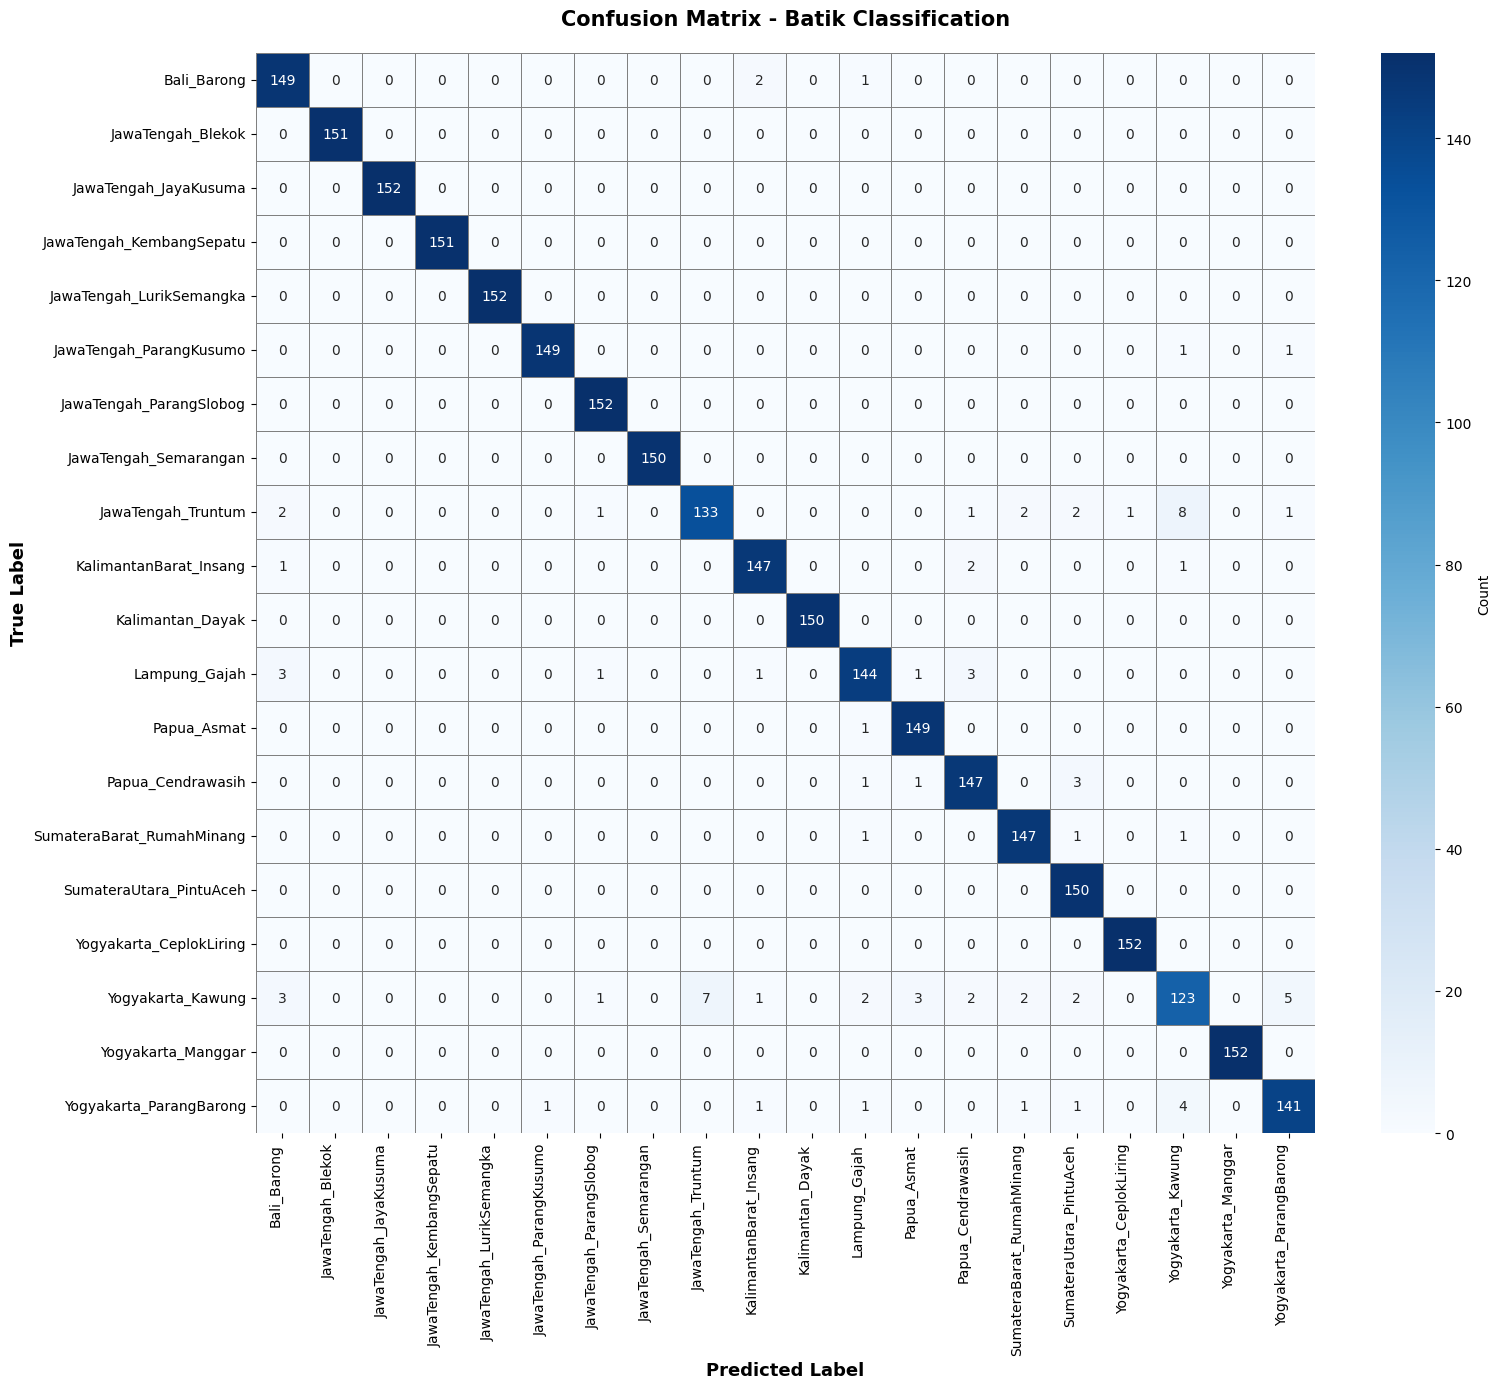

[OK] Confusion matrix heatmap visualized
  Matrix shape: (20, 20)


In [32]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(max(12, len(np.unique(y_test))*0.8), max(10, len(np.unique(y_test))*0.7)))

# Get unique class names
classes = sorted(np.unique(y_test))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='gray')

plt.xlabel('Predicted Label', fontsize=13, weight='bold')
plt.ylabel('True Label', fontsize=13, weight='bold')
plt.title('Confusion Matrix - Batik Classification', fontsize=15, weight='bold', pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("[OK] Confusion matrix heatmap visualized")
print(f"  Matrix shape: {cm.shape}")

### 8.6 Per-Class F1-Score Bar Chart

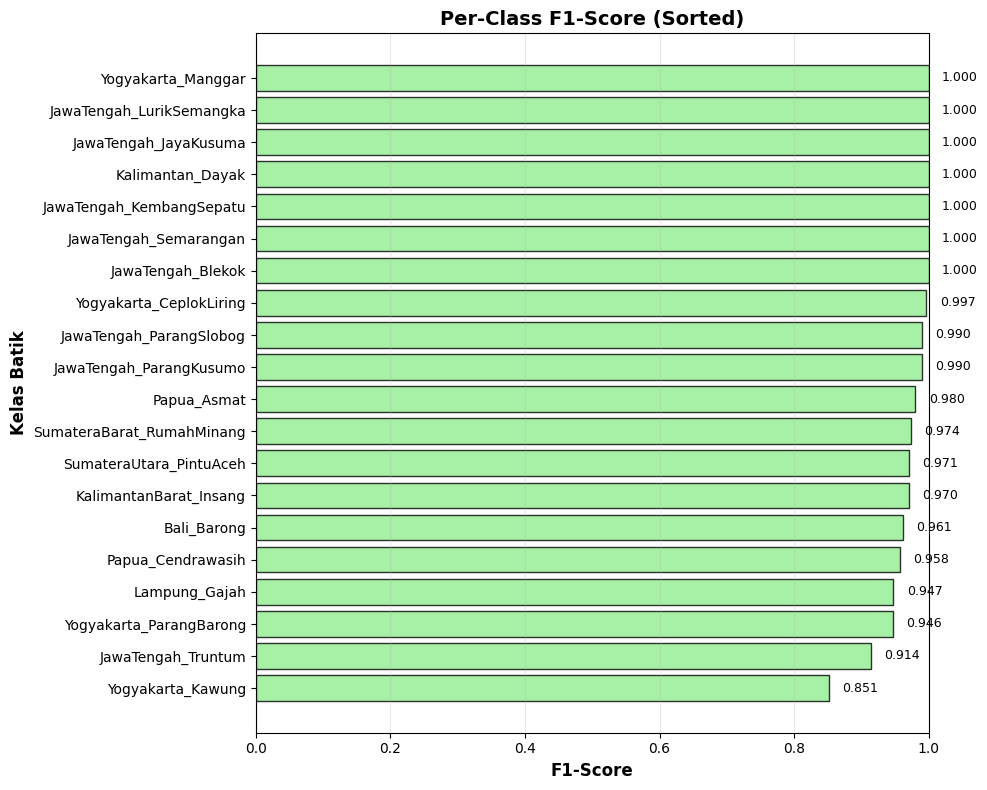

[OK] Per-class F1-scores visualized
  Best performing class: Yogyakarta_Manggar (F1=1.000)
  Worst performing class: Yogyakarta_Kawung (F1=0.851)


In [33]:
# Extract per-class F1-scores
f1_scores_per_class = []
class_labels = []

for class_name in sorted(report_df.index):
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        f1_scores_per_class.append(report_df.loc[class_name, 'f1-score'])
        class_labels.append(class_name)

# Sort by F1-score
sorted_indices = np.argsort(f1_scores_per_class)
f1_scores_sorted = np.array(f1_scores_per_class)[sorted_indices]
class_labels_sorted = np.array(class_labels)[sorted_indices]

# Plot horizontal bar chart
plt.figure(figsize=(10, max(8, len(class_labels)*0.4)))

colors = ['red' if score < 0.5 else 'orange' if score < 0.7 else 'lightgreen'
          for score in f1_scores_sorted]

bars = plt.barh(range(len(class_labels_sorted)), f1_scores_sorted,
                color=colors, edgecolor='black', alpha=0.8)

plt.yticks(range(len(class_labels_sorted)), class_labels_sorted)
plt.xlabel('F1-Score', fontsize=12, weight='bold')
plt.ylabel('Kelas Batik', fontsize=12, weight='bold')
plt.title('Per-Class F1-Score (Sorted)', fontsize=14, weight='bold')
plt.xlim([0, 1])
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, score) in enumerate(zip(bars, f1_scores_sorted)):
    plt.text(score + 0.02, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("[OK] Per-class F1-scores visualized")
print(f"  Best performing class: {class_labels_sorted[-1]} (F1={f1_scores_sorted[-1]:.3f})")
print(f"  Worst performing class: {class_labels_sorted[0]} (F1={f1_scores_sorted[0]:.3f})")